Đây là file tiền xử lý dữ liệu private gốc gồm các giá trị 0, 1, 2, 3 về đoạn 0 - 0.5 - 1


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [ ]:
uploaded = files.upload()

Saving full_pre_01.xlsx to full_pre_01.xlsx


In [ ]:
df_private = pd.read_excel('full_pre_01.xlsx')
df_private.head()

,GioiTinh,TienSuYKhoa,ChamNoi,CungNhac,CoLap,ChoiCamGiac_VanDong,ChoiChucNang,ChoiKetHop,ChoiGiaVo,HanhViLapLai,KyNangGiaoTiepSom,ChoiLuanPhien,BatChuoc,SaiViec,PhanUngTenGoi,DiNhonChan,ChiTro,ChuYLienKet,TiepXucMat,TargetBinary
0,0,3,1,0,1,3,3,2,3,0,1,1,3,1,3,1,3,2,2,1
1,1,3,1,0,1,3,3,3,3,1,1,3,3,2,3,0,1,1,2,1
2,1,3,1,0,0,3,3,3,2,0,1,3,3,3,1,0,2,1,1,1
3,0,3,0,0,0,2,3,1,1,1,1,3,1,3,1,1,1,2,2,1
4,1,3,1,0,0,2,3,1,1,0,1,3,1,3,1,0,1,2,2,1


# MÃ HÓA DF_PRIVATE VỀ GIÁ TRỊ 0-1 LÀM CHUẨN

In [ ]:
# Liệt kê tên các cột
print(df_private.columns.tolist())
rows, cols = df_private.shape
print(f"Số hàng: {rows}, Số cột: {cols}")

['GioiTinh', 'TienSuYKhoa', 'ChamNoi', 'CungNhac', 'CoLap', 'ChoiCamGiac_VanDong', 'ChoiChucNang', 'ChoiKetHop', 'ChoiGiaVo', 'HanhViLapLai', 'KyNangGiaoTiepSom', 'ChoiLuanPhien', 'BatChuoc', 'SaiViec', 'PhanUngTenGoi', 'DiNhonChan', 'ChiTro', 'ChuYLienKet', 'TiepXucMat', 'TargetBinary']
Số hàng: 593, Số cột: 20


In [ ]:
# Tìm các cột có giá trị ngoài 0-1
invalid_cols = [col for col in df_private.columns if not df_private[col].isin([0, 1]).all()]

# Hiển thị tất cả giá trị duy nhất (gồm cả 0 và 1) trong từng cột
for col in invalid_cols:
    unique_vals = df_private[col].unique()
    print(f"{col}: {unique_vals}")

TienSuYKhoa: [3 2 1]
ChoiCamGiac_VanDong: [3 2 1]
ChoiChucNang: [3 1 2]
ChoiKetHop: [2 3 1]
ChoiGiaVo: [3 2 1]
KyNangGiaoTiepSom: [1 2 3]
ChoiLuanPhien: [1 3 2]
BatChuoc: [3 1 2]
SaiViec: [1 2 3]
PhanUngTenGoi: [3 1 2]
ChiTro: [3 1 2]
ChuYLienKet: [2 1 3]
TiepXucMat: [2 1 3]


In [ ]:
# TienSuYKhoa: [3 2 1]
# mapping = {
#     'tiensuykhoatiensusausinh': 1,
#     'tiensuykhoatiensusinh': 2,
#     'khong': 3
# }
# --> 3: 0, 2: 1, 1: 1
df_private['TienSuYKhoa'] = np.where(df_private['TienSuYKhoa'] == 3, 0, 1)

In [ ]:
# ChoiCamGiac_VanDong: [3 2 1]
# mapping = {
#     'khongdgbt': 3,
#     'conghingo': 2,
#     'conguyco': 1
# }
# --> 3: 0, 2: 0.5, 1: 1
df_private['ChoiCamGiac_VanDong'] = df_private['ChoiCamGiac_VanDong'].replace({
    3: 0,
    2: 0.5,
    1: 1
})

In [ ]:
# ChoiChucNang: [3 1 2], ChoiKetHop: [2 3 1], ChoiGiaVo: [3 2 1], KyNangGiaoTiepSom: [1 2 3], ChoiLuanPhien: [1 3 2], BatChuoc: [3 1 2], SaiViec: [1 2 3], PhanUngTenGoi: [3 1 2], ChiTro: [3 1 2]

# mapping = {
#     'cotot': 3,
#     'khongdg': 3,
#     'cokha': 2,
#     'cokem': 1
# }
# --> 3: 0, 2: 0.5, 1: 1
mapping = {3: 0, 2: 0.5, 1: 1}

columns_to_map = [
    'ChoiChucNang',
    'ChoiKetHop',
    'ChoiGiaVo',
    'KyNangGiaoTiepSom',
    'ChoiLuanPhien',
    'BatChuoc',
    'SaiViec',
    'PhanUngTenGoi',
    'ChiTro'
]

for col in columns_to_map:
    df_private[col] = df_private[col].replace(mapping)

In [ ]:
# ChuYLienKet: [2 1 3], TiepXucMat: [2 1 3]
# mapping = {
#     'cotot': 3,
#     'cokha': 2,
#     'cokem': 1
# } --> 3=0 ; 2=0.5 ; 1=1
mapping = {3: 0, 2: 0.5, 1: 1}

df_private['ChuYLienKet'] = df_private['ChuYLienKet'].replace(mapping)
df_private['TiepXucMat'] = df_private['TiepXucMat'].replace(mapping)

In [ ]:
df_private.head()

,GioiTinh,TienSuYKhoa,ChamNoi,CungNhac,CoLap,ChoiCamGiac_VanDong,ChoiChucNang,ChoiKetHop,ChoiGiaVo,HanhViLapLai,KyNangGiaoTiepSom,ChoiLuanPhien,BatChuoc,SaiViec,PhanUngTenGoi,DiNhonChan,ChiTro,ChuYLienKet,TiepXucMat,TargetBinary
0,0,0,1,0,1,0.0,0.0,0.5,0.0,0,1.0,1.0,0.0,1.0,0.0,1,0.0,0.5,0.5,1
1,1,0,1,0,1,0.0,0.0,0.0,0.0,1,1.0,0.0,0.0,0.5,0.0,0,1.0,1.0,0.5,1
2,1,0,1,0,0,0.0,0.0,0.0,0.5,0,1.0,0.0,0.0,0.0,1.0,0,0.5,1.0,1.0,1
3,0,0,0,0,0,0.5,0.0,1.0,1.0,1,1.0,0.0,1.0,0.0,1.0,1,1.0,0.5,0.5,1
4,1,0,1,0,0,0.5,0.0,1.0,1.0,0,1.0,0.0,1.0,0.0,1.0,0,1.0,0.5,0.5,1


In [ ]:
df_private[col].unique()

array([0. , 1. , 0.5])

# Mô hình hóa dữ liệu

In [ ]:
from scipy.stats import shapiro
stat, p = shapiro(df_private)
if p < 0.05:
    print("Không phân phối chuẩn")

Không phân phối chuẩn


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11860.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
for i, col in enumerate(df_private.columns):
    print(f"Vị trí {i}: {col}")

Vị trí 0: GioiTinh
Vị trí 1: TienSuYKhoa
Vị trí 2: ChamNoi
Vị trí 3: CungNhac
Vị trí 4: CoLap
Vị trí 5: ChoiCamGiac_VanDong
Vị trí 6: ChoiChucNang
Vị trí 7: ChoiKetHop
Vị trí 8: ChoiGiaVo
Vị trí 9: HanhViLapLai
Vị trí 10: KyNangGiaoTiepSom
Vị trí 11: ChoiLuanPhien
Vị trí 12: BatChuoc
Vị trí 13: SaiViec
Vị trí 14: PhanUngTenGoi
Vị trí 15: DiNhonChan
Vị trí 16: ChiTro
Vị trí 17: ChuYLienKet
Vị trí 18: TiepXucMat
Vị trí 19: TargetBinary


In [ ]:
# Kiểm tra số lượng giá trị duy nhất
for col in df_private.columns:
    unique_vals = df_private[col].nunique(dropna=True)
    if unique_vals <= 3:
        print(f"Cột '{col}' chỉ có {unique_vals} giá trị duy nhất.")

Cột 'GioiTinh' chỉ có 2 giá trị duy nhất.
Cột 'TienSuYKhoa' chỉ có 2 giá trị duy nhất.
Cột 'ChamNoi' chỉ có 2 giá trị duy nhất.
Cột 'CungNhac' chỉ có 2 giá trị duy nhất.
Cột 'CoLap' chỉ có 2 giá trị duy nhất.
Cột 'ChoiCamGiac_VanDong' chỉ có 3 giá trị duy nhất.
Cột 'ChoiChucNang' chỉ có 3 giá trị duy nhất.
Cột 'ChoiKetHop' chỉ có 3 giá trị duy nhất.
Cột 'ChoiGiaVo' chỉ có 3 giá trị duy nhất.
Cột 'HanhViLapLai' chỉ có 2 giá trị duy nhất.
Cột 'KyNangGiaoTiepSom' chỉ có 3 giá trị duy nhất.
Cột 'ChoiLuanPhien' chỉ có 3 giá trị duy nhất.
Cột 'BatChuoc' chỉ có 3 giá trị duy nhất.
Cột 'SaiViec' chỉ có 3 giá trị duy nhất.
Cột 'PhanUngTenGoi' chỉ có 3 giá trị duy nhất.
Cột 'DiNhonChan' chỉ có 2 giá trị duy nhất.
Cột 'ChiTro' chỉ có 3 giá trị duy nhất.
Cột 'ChuYLienKet' chỉ có 3 giá trị duy nhất.
Cột 'TiepXucMat' chỉ có 3 giá trị duy nhất.
Cột 'TargetBinary' chỉ có 2 giá trị duy nhất.


Hoán vị tầm quan trọng của tính năng là một kỹ thuật để tính điểm quan trọng tương đối độc lập với mô hình được sử dụng. KNN

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Lấy dữ liệu đầu vào (không gồm cột target)
X = df_private.drop(columns='TargetBinary')

# 2. Chuẩn hóa dữ liệu (nên làm trước khi dùng PCA)
scaler = StandardScaler()
Z = scaler.fit_transform(X)

# 3. Khởi tạo và tính PCA với 2 thành phần chính
n_components = 2
pca = PCA(n_components=n_components)
x_pca = pca.fit_transform(Z)

# 4. Tạo DataFrame kết quả
df_pca = pd.DataFrame(x_pca,
                      columns=[f'PC{i+1}' for i in range(n_components)])

# 5. In kết quả
print(df_pca.head())


        PC1       PC2
0  0.040457 -2.172643
1  0.335339 -0.915592
2 -0.097828  1.353732
3 -0.491938  3.425537
4 -0.266171  3.535124


In [ ]:
# components
pca.components_

array([[ 0.04261807,  0.03790926,  0.28519523,  0.13168519,  0.27856784,
         0.11845836,  0.10180513,  0.02100968, -0.03467603,  0.15159236,
         0.32548513,  0.30855989,  0.09431805,  0.28930276,  0.30915149,
         0.10640094,  0.2931766 ,  0.39860472,  0.35492631],
       [ 0.05068974,  0.04639194, -0.06234692, -0.35796154, -0.36743321,
         0.08276422, -0.1327025 ,  0.06588942,  0.41597104, -0.09874287,
         0.20608055, -0.2853891 ,  0.37669993, -0.26157997,  0.27425165,
         0.02842775,  0.2805843 ,  0.09367116,  0.13746723]])

In [ ]:
X = df_private.iloc[:, 0:19]      # lấy từ cột 0 đến 13 (14 đặc trưng)
y = df_private.iloc[:, 19]

MÃ HÓA

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Xác định cột
numerical_ix = X.select_dtypes(include=['int64', 'float64']).columns
categorical_ix = X.select_dtypes(include=['object', 'bool']).columns

# 2. Fit riêng OneHotEncoder để lấy tên
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X[categorical_ix])
cat_feature_names = ohe.get_feature_names_out(categorical_ix)

# 3. Xây dựng ColumnTransformer dùng lại ohe đã fit
preprocessor = ColumnTransformer(transformers=[
    ('cat', ohe, categorical_ix),
    ('num', MinMaxScaler(), numerical_ix)
])

# 4. Fit + transform toàn bộ
X_transformed = preprocessor.fit_transform(X)

# 5. Kết hợp tên cột đầy đủ
all_columns = list(cat_feature_names) + list(numerical_ix)

# 6. Tạo DataFrame kết quả
df_transformed = pd.DataFrame(X_transformed, columns=all_columns)

# 7. In kết quả
print(df_transformed.head())


   GioiTinh  TienSuYKhoa  ChamNoi  CungNhac  CoLap  ChoiCamGiac_VanDong  \
0       0.0          0.0      1.0       0.0    1.0                  0.0   
1       1.0          0.0      1.0       0.0    1.0                  0.0   
2       1.0          0.0      1.0       0.0    0.0                  0.0   
3       0.0          0.0      0.0       0.0    0.0                  0.5   
4       1.0          0.0      1.0       0.0    0.0                  0.5   

   ChoiChucNang  ChoiKetHop  ChoiGiaVo  HanhViLapLai  KyNangGiaoTiepSom  \
0           0.0         0.5        0.0           0.0                1.0   
1           0.0         0.0        0.0           1.0                1.0   
2           0.0         0.0        0.5           0.0                1.0   
3           0.0         1.0        1.0           1.0                1.0   
4           0.0         1.0        1.0           0.0                1.0   

   ChoiLuanPhien  BatChuoc  SaiViec  PhanUngTenGoi  DiNhonChan  ChiTro  \
0            1.0       0

In [ ]:
# Giả sử y là Series gốc chứa TargetBinary
df_private = df_transformed.copy()
df_private['TargetBinary'] = y.loc[df_transformed.index].values

# Xem kết quả
print(df_private.head())


   GioiTinh  TienSuYKhoa  ChamNoi  CungNhac  CoLap  ChoiCamGiac_VanDong  \
0       0.0          0.0      1.0       0.0    1.0                  0.0   
1       1.0          0.0      1.0       0.0    1.0                  0.0   
2       1.0          0.0      1.0       0.0    0.0                  0.0   
3       0.0          0.0      0.0       0.0    0.0                  0.5   
4       1.0          0.0      1.0       0.0    0.0                  0.5   

   ChoiChucNang  ChoiKetHop  ChoiGiaVo  HanhViLapLai  KyNangGiaoTiepSom  \
0           0.0         0.5        0.0           0.0                1.0   
1           0.0         0.0        0.0           1.0                1.0   
2           0.0         0.0        0.5           0.0                1.0   
3           0.0         1.0        1.0           1.0                1.0   
4           0.0         1.0        1.0           0.0                1.0   

   ChoiLuanPhien  BatChuoc  SaiViec  PhanUngTenGoi  DiNhonChan  ChiTro  \
0            1.0       0

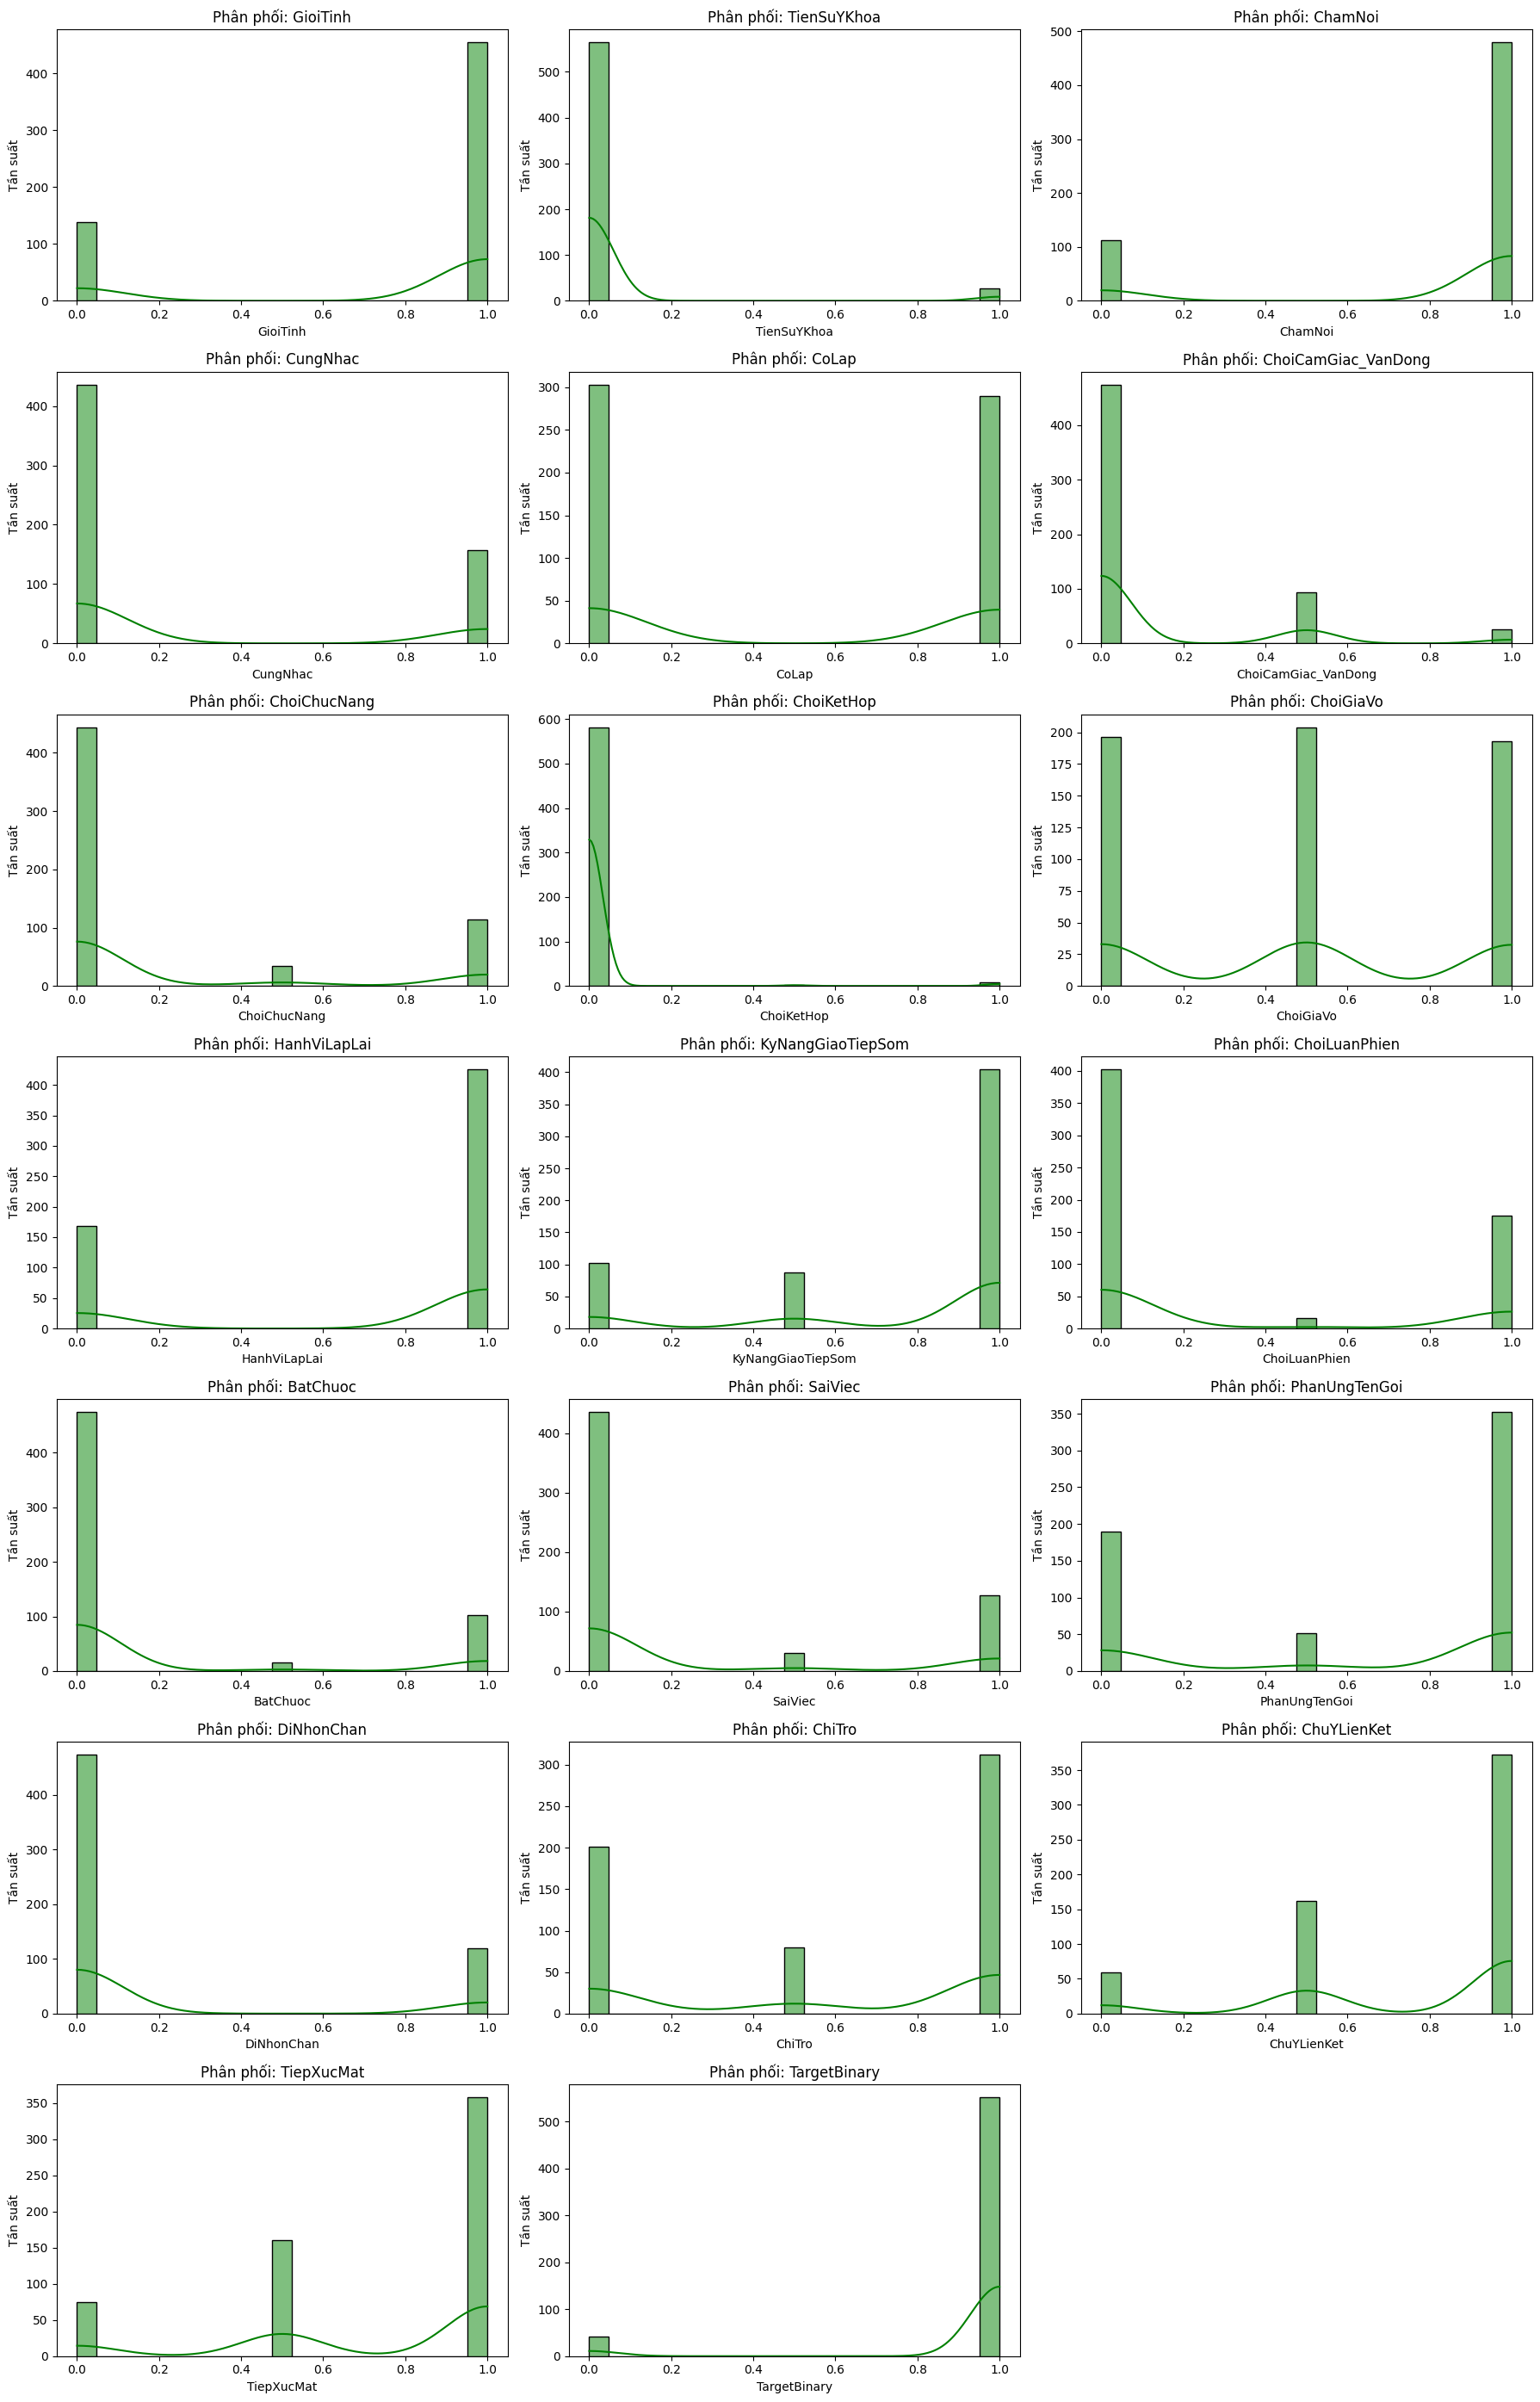

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Giả sử df_private là DataFrame với ít nhất 19 cột
feature_cols = df_private.columns[:20]
n_features = len(feature_cols)

# Tính toán số hàng và cột cho lưới (ví dụ 3 cột)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

# Tạo lưới subplot phù hợp
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Vẽ từng histogram
for i, feature in enumerate(feature_cols):
    sns.histplot(df_private[feature], bins=21, kde=True, color='green', ax=axes[i])
    axes[i].set_title(f'Phân phối: {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Tần suất')

# Tắt các subplot thừa nếu có
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


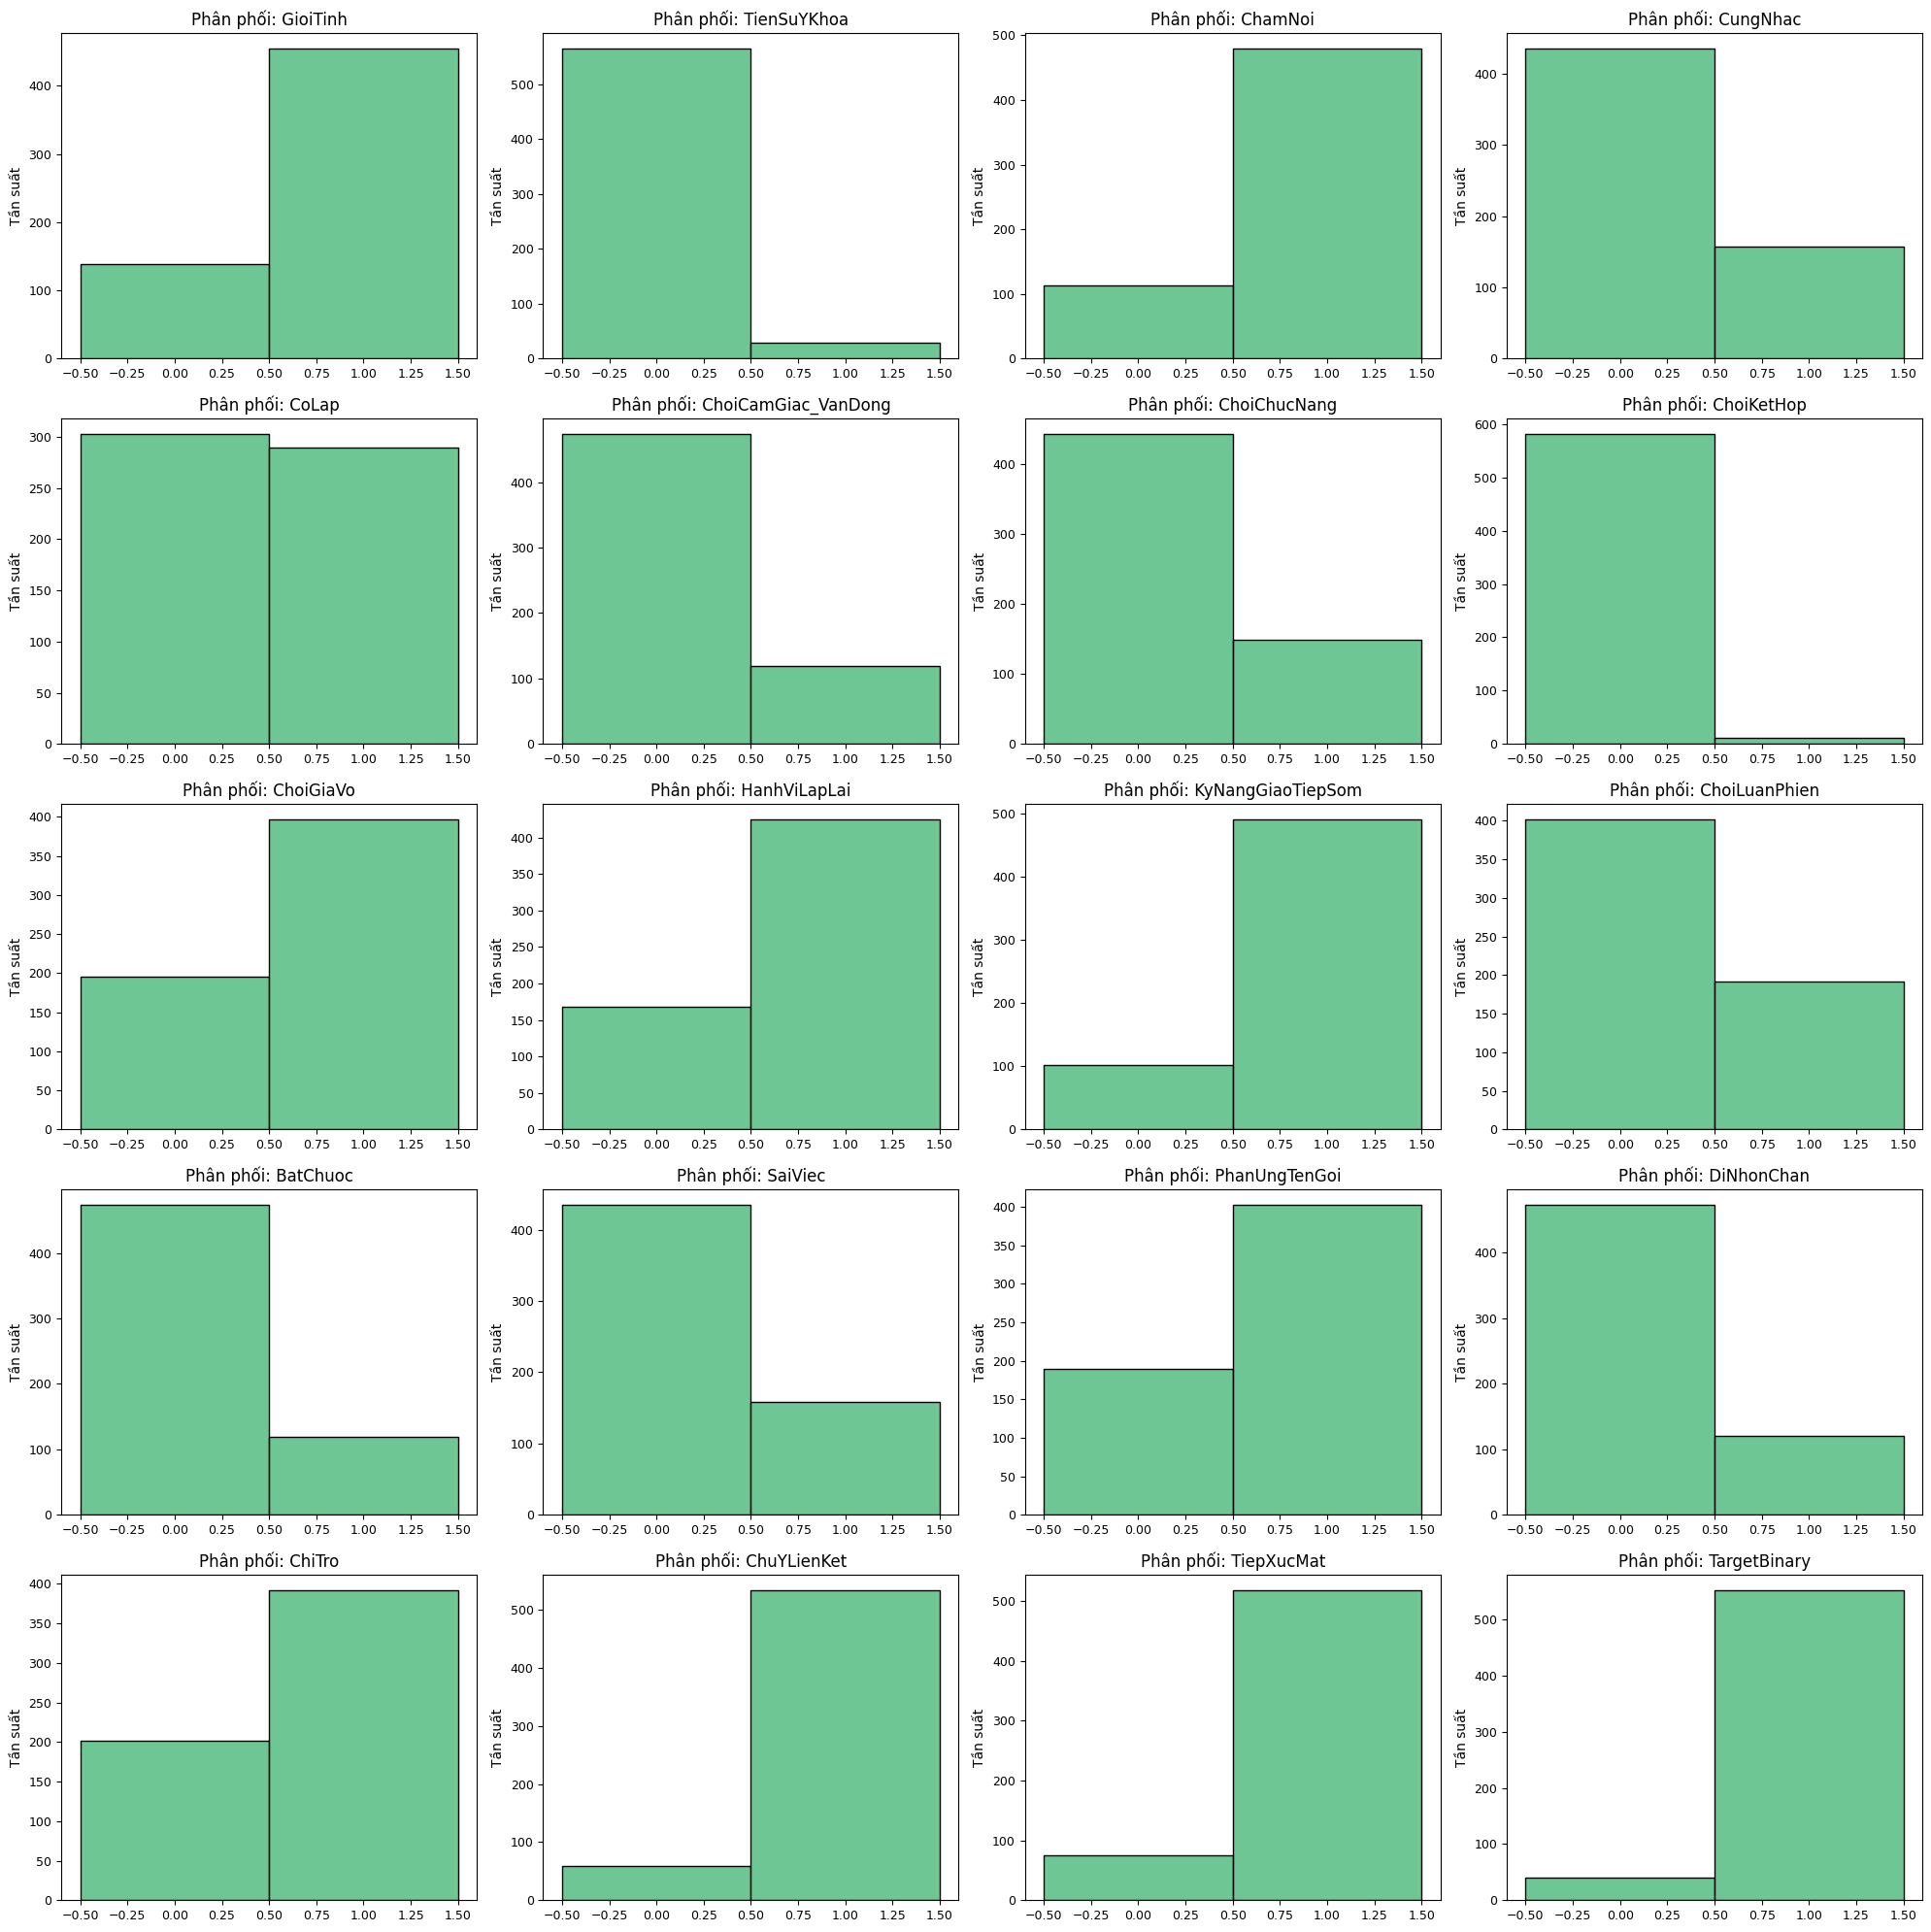

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Kiểm tra phân phối, lệch lớp Histogram


# Lấy các cột đặc trưng, loại trừ cột TargetBinary nếu muốn
feature_cols = df_private.columns[:20]  # bỏ TargetBinary nếu cần vẽ riêng

# Tạo lưới 5 hàng x 4 cột (20 biểu đồ), dư ra 1 slot nếu sau này thêm 1 cột
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()  # Flatten để dễ lặp

for i, feature in enumerate(feature_cols):
    sns.histplot(df_private[feature], bins=range(0, 5), discrete=True, color='mediumseagreen', ax=axes[i])
    axes[i].set_title(f'Phân phối: {feature}', fontsize=12)
    axes[i].set_xlabel('', fontsize=10)
    axes[i].set_ylabel('Tần suất', fontsize=10)
    axes[i].tick_params(axis='x', labelsize=9)
    axes[i].tick_params(axis='y', labelsize=9)

# Xoá các ô dư không sử dụng
for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

# Căn chỉnh lại layout
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import kendalltau
import pandas as pd
# 2. Kendall's Tau (Tương quan thứ bậc Kendall) giữa features và target
results = []

for col in df_private.columns[:-1]:  # Trừ cột TargetBinary
    corr, p = kendalltau(df_private[col], df_private['TargetBinary'])
    strength = ""
    if p < 0.05:
        if abs(corr) >= 0.3:
            strength = "Tương quan mạnh"
        elif abs(corr) >= 0.2:
            strength = "Tương quan vừa"
        else:
            strength = "Tương quan yếu"
        significance = "✅ Có ý nghĩa thống kê"
    else:
        strength = "-"
        significance = "❌ Không có ý nghĩa"

    results.append({
        "Đặc trưng": col,
        "Kendall's Tau": round(corr, 3) if corr is not None else None,
        "p-value": round(p, 3) if p is not None else None,
        "Mức độ tương quan": strength,
        "Ý nghĩa thống kê": significance
    })

# Chuyển kết quả thành DataFrame
df_kendall_analysis = pd.DataFrame(results)

# In toàn bộ kết quả
print(df_kendall_analysis.to_string(index=False))


          Đặc trưng  Kendall's Tau  p-value Mức độ tương quan      Ý nghĩa thống kê
           GioiTinh          0.102    0.013    Tương quan yếu ✅ Có ý nghĩa thống kê
        TienSuYKhoa          0.061    0.140                 -    ❌ Không có ý nghĩa
            ChamNoi          0.494    0.000   Tương quan mạnh ✅ Có ý nghĩa thống kê
           CungNhac          0.133    0.001    Tương quan yếu ✅ Có ý nghĩa thống kê
              CoLap          0.200    0.000    Tương quan vừa ✅ Có ý nghĩa thống kê
ChoiCamGiac_VanDong          0.053    0.192                 -    ❌ Không có ý nghĩa
       ChoiChucNang          0.014    0.720                 -    ❌ Không có ý nghĩa
         ChoiKetHop          0.037    0.362                 -    ❌ Không có ý nghĩa
          ChoiGiaVo          0.021    0.586                 -    ❌ Không có ý nghĩa
       HanhViLapLai          0.183    0.000    Tương quan yếu ✅ Có ý nghĩa thống kê
  KyNangGiaoTiepSom          0.395    0.000   Tương quan mạnh ✅ Có ý nghĩa t

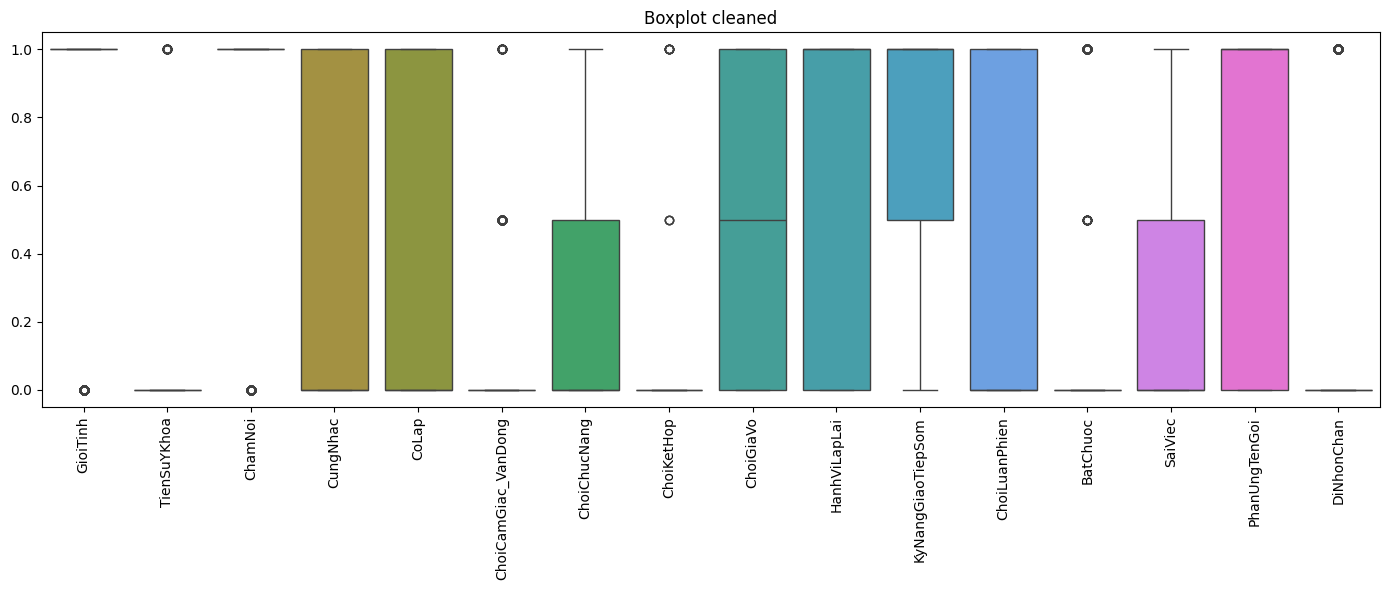

In [ ]:
selected_columns = df_private.columns[:16]

# 3. Vẽ boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_private[selected_columns])
plt.xticks(rotation=90)
plt.title("Boxplot cleaned")
plt.tight_layout()
plt.show()

<ipython-input-35-c91a4a190719>:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], estimator=np.mean, ci=None)
<ipython-input-35-c91a4a190719>:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], estimator=np.mean, ci=None)
<ipython-input-35-c91a4a190719>:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], estimator=np.mean, ci=None)
<ipython-input-35-c91a4a190719>:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], estimator=np.mean, ci=None)
<ipython-input-35-c91a4a190719>:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar

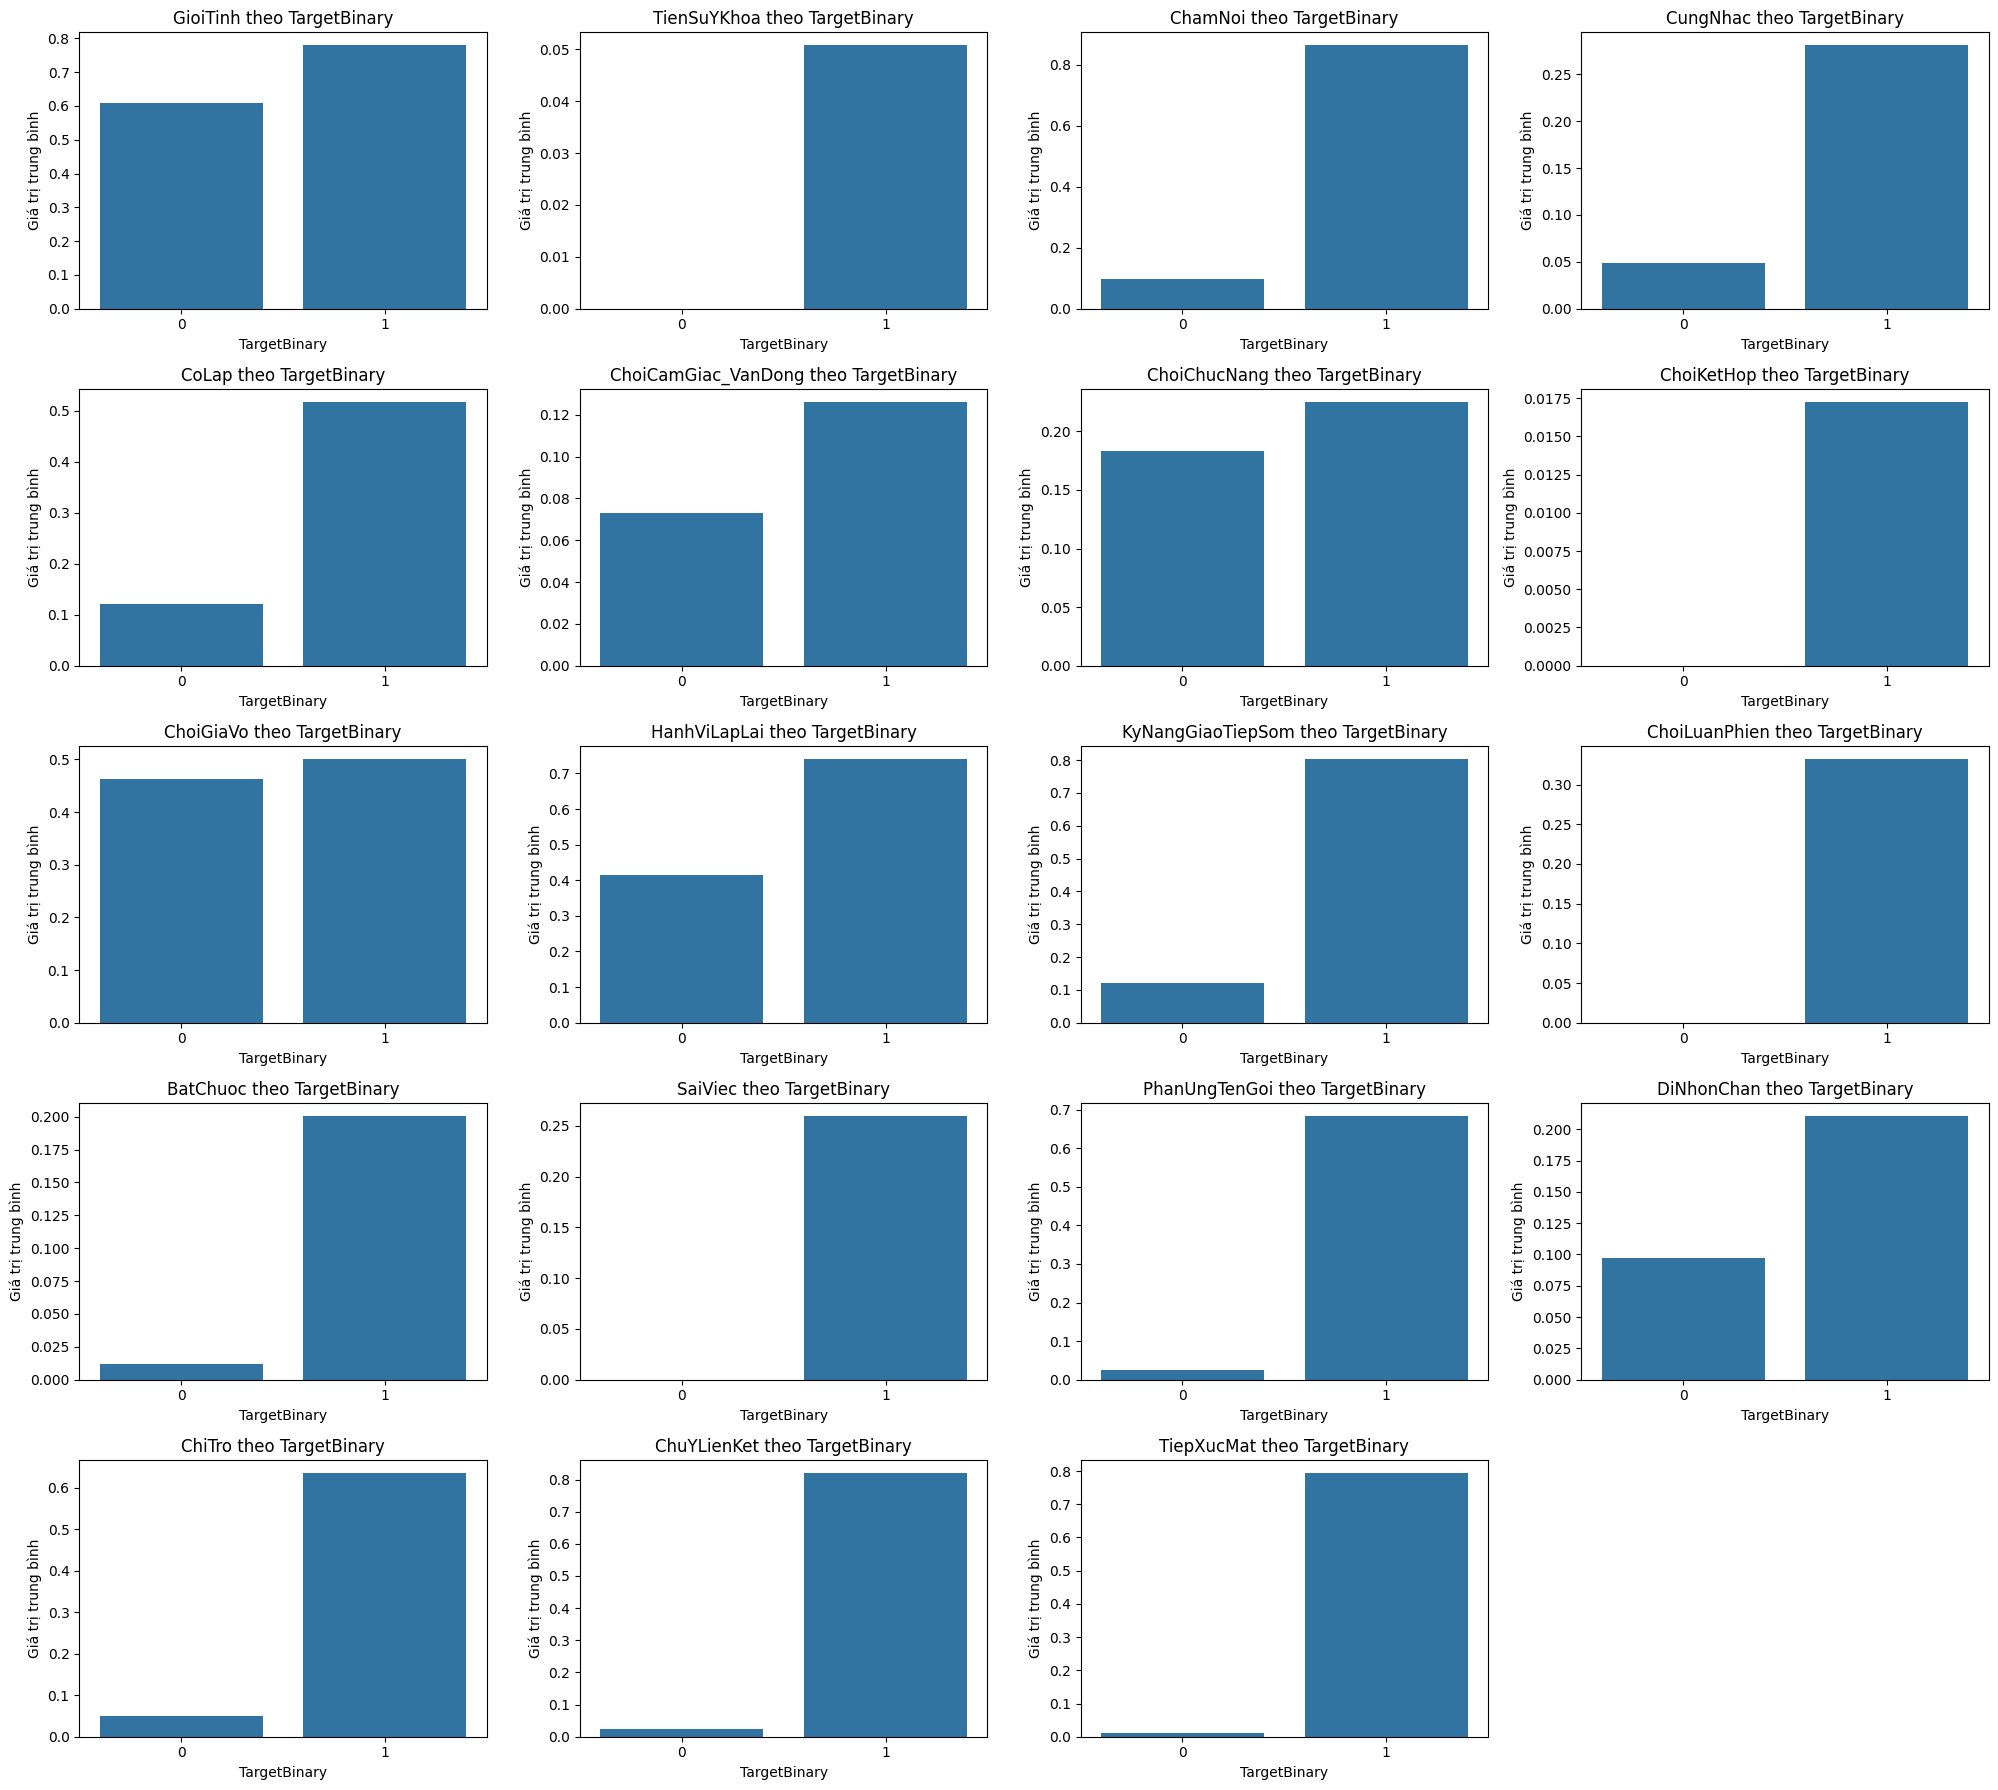

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# 4. Barplot giữa các đặc trưng và target


# Lấy danh sách cột đặc trưng (trừ TargetBinary)
feature_cols = [col for col in df_private.columns if col != 'TargetBinary']

# Tạo lưới 5x4 để vẽ tối đa 20 cột
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 18))
axes = axes.flatten()

# Vẽ barplot cho từng cột theo nhóm TargetBinary
for i, col in enumerate(feature_cols):
    sns.barplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], estimator=np.mean, ci=None)
    axes[i].set_title(f"{col} theo TargetBinary")
    axes[i].set_xlabel("TargetBinary")
    axes[i].set_ylabel("Giá trị trung bình")

# Xoá các ô dư nếu feature < 20
for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


<ipython-input-36-7dda5bace061>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], inner='quartile', palette='Set2')
<ipython-input-36-7dda5bace061>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], inner='quartile', palette='Set2')
<ipython-input-36-7dda5bace061>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], inner='quartile', palette='Set2')
<ipython-input-36-7dda5bace0

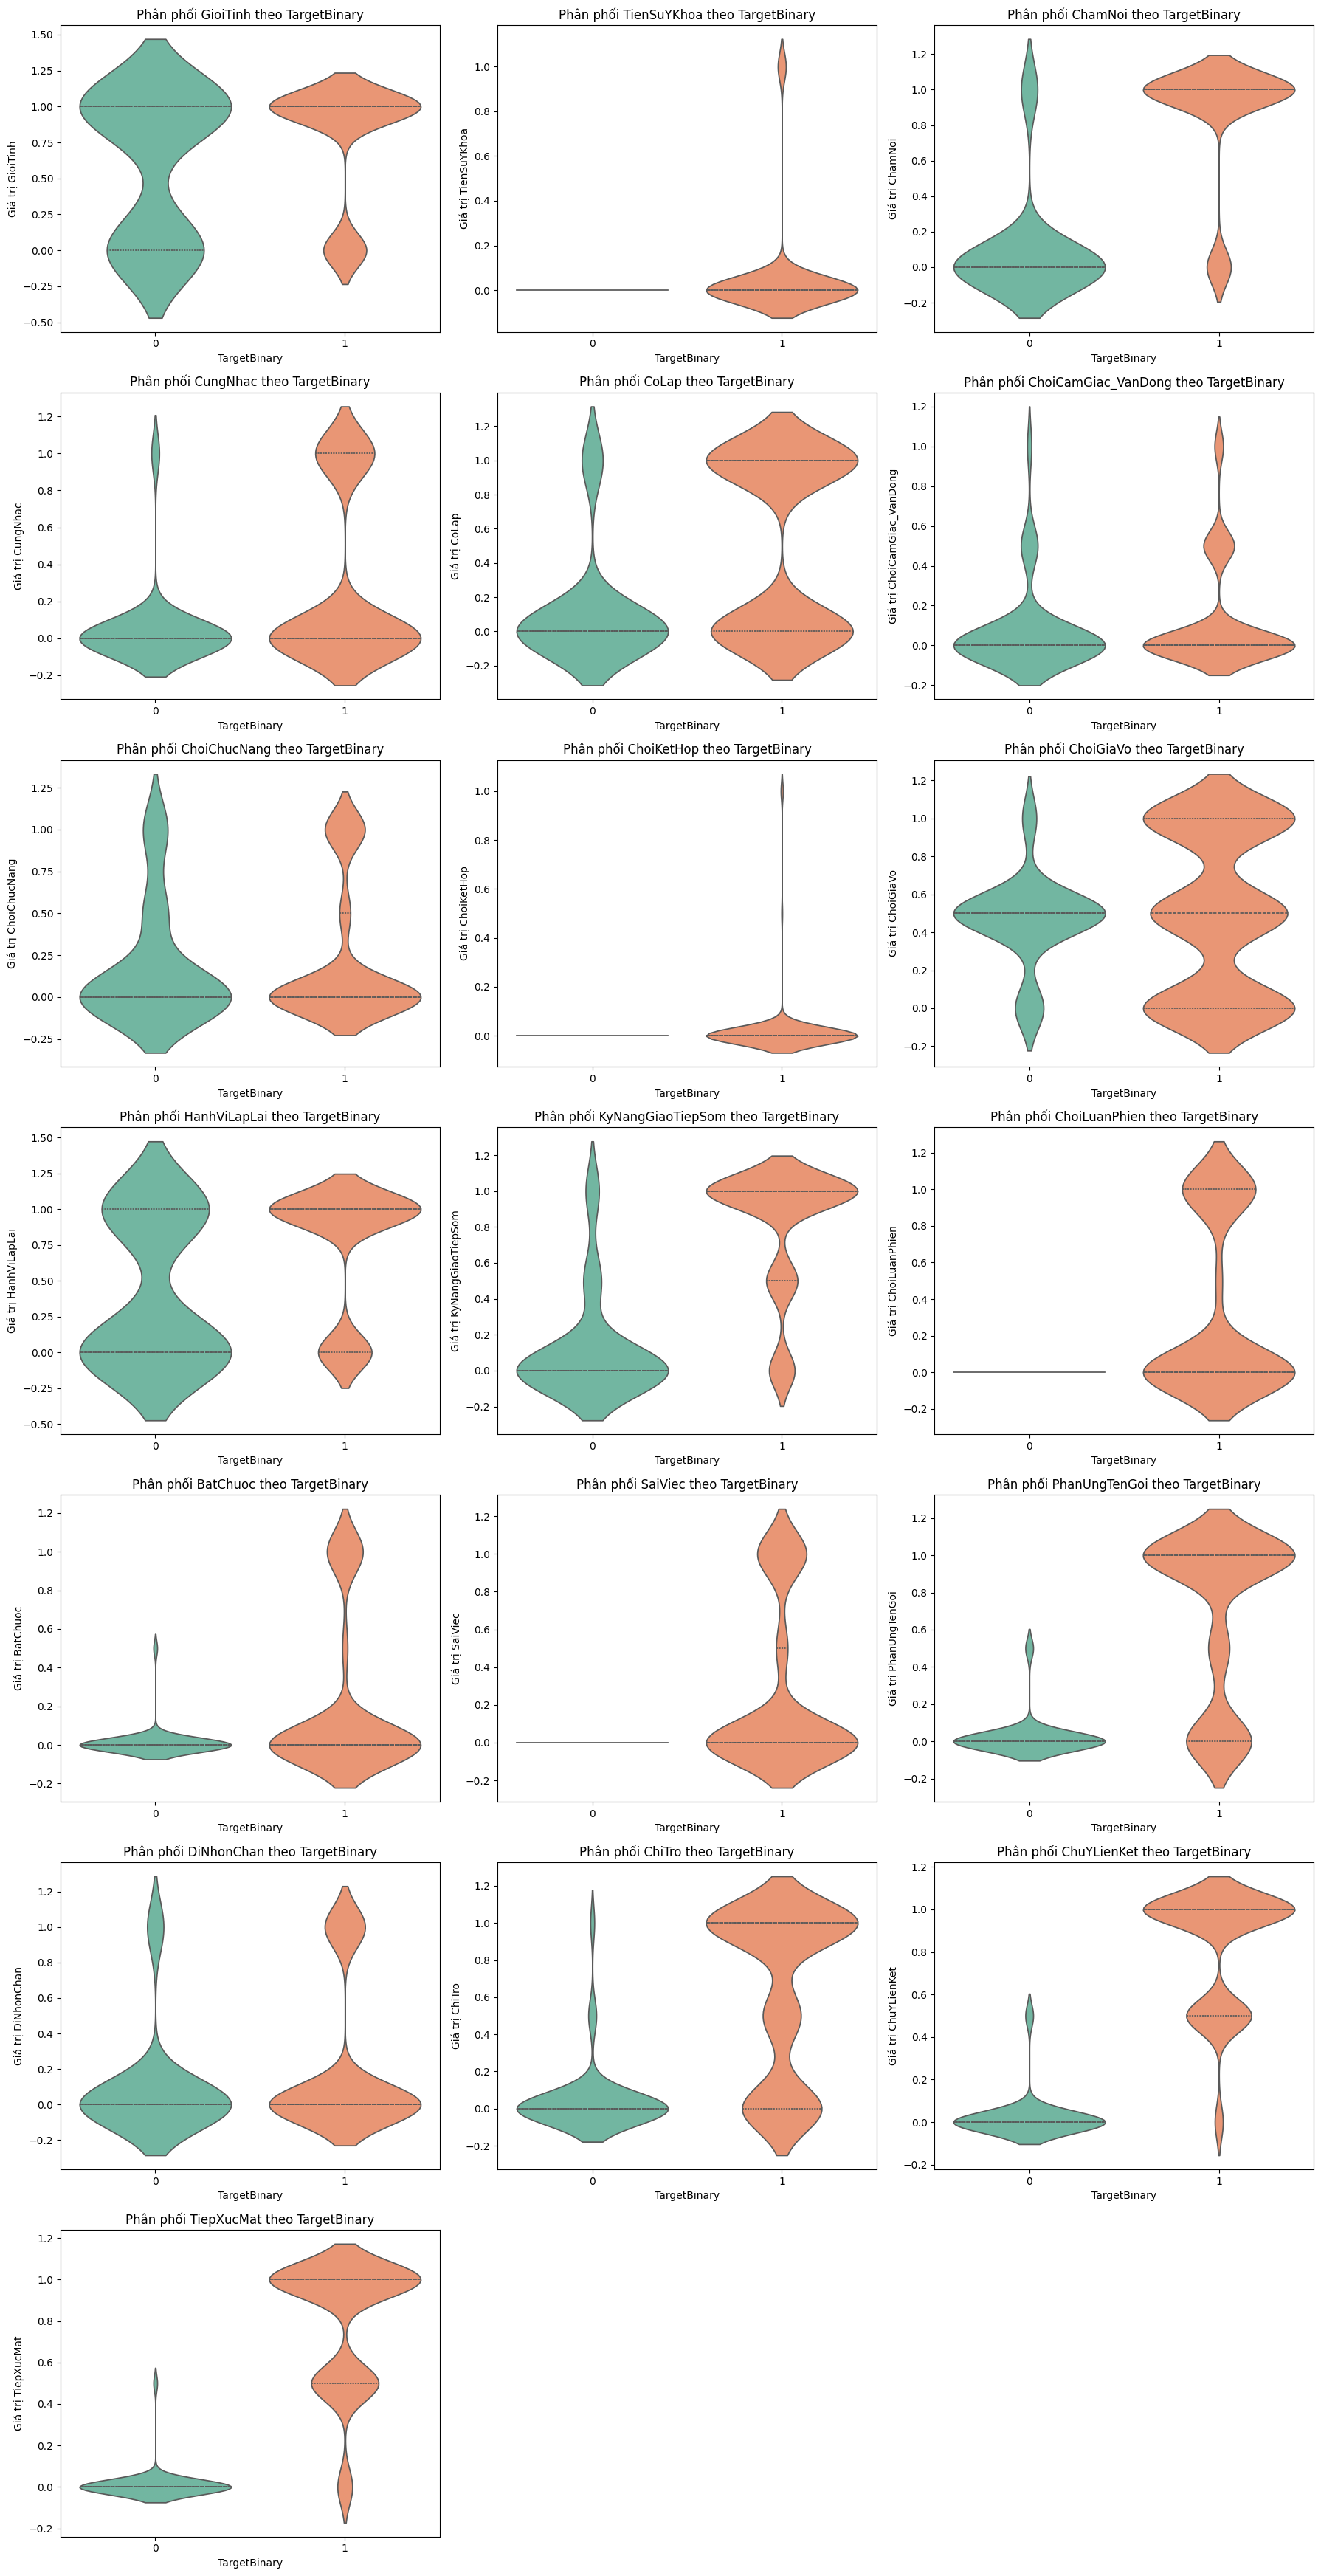

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Violin plot

# Lấy danh sách cột đặc trưng (trừ TargetBinary)
feature_cols = [col for col in df_private.columns if col != 'TargetBinary']

# Thiết lập lưới để hiển thị tất cả violin plots cho các đặc trưng
num_features = len(feature_cols)
rows = (num_features + 2) // 3  # 3 cột mỗi hàng
fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))
axes = axes.flatten()

# Vẽ từng biểu đồ violin
for i, col in enumerate(feature_cols):
    sns.violinplot(x='TargetBinary', y=col, data=df_private, ax=axes[i], inner='quartile', palette='Set2')
    axes[i].set_title(f'Phân phối {col} theo TargetBinary')
    axes[i].set_xlabel('TargetBinary')
    axes[i].set_ylabel(f'Giá trị {col}')

# Ẩn các ô dư nếu số cột không chia hết cho 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



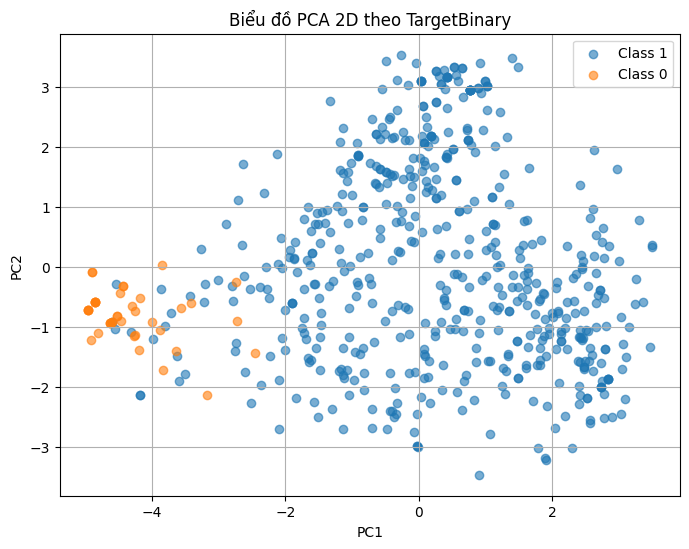

In [ ]:
import matplotlib.pyplot as plt

# Thêm label từ target để phân biệt nhóm
df_pca['Target'] = y.loc[df_pca.index].values

# Vẽ biểu đồ PC1 vs PC2, tô màu theo target
plt.figure(figsize=(8,6))
for label in df_pca['Target'].unique():
    subset = df_pca[df_pca['Target'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=f"Class {label}", alpha=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biểu đồ PCA 2D theo TargetBinary")
plt.legend()
plt.grid()
plt.show()


https://github.com/apachecn/ml-mastery-zh-pt2/blob/master/docs/ensemble/dynamic-classifier-selection-in-python.md

In [ ]:
df_private.to_excel("data_private_final_3value.xlsx", index=False)